# 08 - XGBoost Classifier

**Responsable** : Personne 4

**Objectif** : Entraîner un XGBoost Classifier et évaluer ses performances.

**Étapes** :
1. Chargement des données (sortie du notebook 06)
2. Entraînement du XGBoost
3. Prédiction sur le jeu de test
4. Évaluation : Accuracy, Precision, Recall, F1-score (macro)
5. Matrice de confusion
6. Feature Importance (top 20)
7. Analyse des erreurs par classe
8. Sauvegarde du modèle et des résultats

**Justification du choix** : XGBoost est un algorithme de boosting performant, souvent meilleur que RF sur des données tabulaires. La comparaison RF vs XGBoost permet d'évaluer si le boosting apporte un gain par rapport au bagging.

**Note sur la PCA** : Nous avons testé la PCA (95% de variance) mais la première composante captait déjà ~98% de la variance, réduisant les 175 features à 1 seule composante. Cette réduction trop agressive faisait perdre du signal utile. Nous avons donc choisi de travailler directement sur les 175 features originales.

**Installation** : `pip install xgboost` si nécessaire.

## 1. Chargement des données

In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from xgboost import XGBClassifier

# ==============================
# CHARGEMENT DES DONNÉES (5 classes)
# ==============================
# Ces fichiers contiennent les classes 0,1,2,3,4
X_train = np.load('../data/processed/X_train.npy', allow_pickle=True)
X_test = np.load('../data/processed/X_test.npy', allow_pickle=True)
y_train = np.load('../data/processed/y_train.npy', allow_pickle=True)
y_test = np.load('../data/processed/y_test.npy', allow_pickle=True)

# Noms des features (pour feature importance)
feature_names = pd.read_csv('../data/processed/feature_names.csv').iloc[:, 0].tolist()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print(f"Nombre de features : {len(feature_names)}")
print(f"\nClasses originales : {np.unique(y_train)}")  # [0 1 2 3 4]

X_train : (13049, 325)
X_test  : (3263, 325)
y_train : (13049,)
y_test  : (3263,)
Nombre de features : 325

Classes originales : [0 1 2 3 4]


In [165]:
# ==============================
# FONCTIONS DE TRANSFORMATION DES CLASSES
# ==============================

def to_3_classes(y):
    """
    Transforme 5 classes en 3 classes :
    0-1 -> 0 (Mauvais)
    2   -> 1 (Moyen)
    3-4 -> 2 (Bon)
    """
    y_new = y.copy()
    y_new[y_new <= 1] = 0   # Mauvais
    y_new[y_new == 2] = 1   # Moyen
    y_new[y_new >= 3] = 2   # Bon
    return y_new

def to_2_classes(y):
    """
    Transforme 5 classes en 2 classes (supprime la classe 2) :
    0-1 -> 0 (Mauvais)
    3-4 -> 1 (Bon)
    La classe 2 est exclue
    """
    return (y >= 3).astype(int)

# Création des versions transformées
y_train_3 = to_3_classes(y_train)
y_test_3 = to_3_classes(y_test)

# Pour la version 2 classes, on supprime la classe "Moyen" (2)
mask_train = (y_train != 2)
mask_test = (y_test != 2)

X_train_bin = X_train[mask_train]
X_test_bin = X_test[mask_test]
y_train_bin = to_2_classes(y_train[mask_train])
y_test_bin = to_2_classes(y_test[mask_test])

print("\n=== DISTRIBUTION DES CLASSES ===")
print(f"5 classes - Train : {np.unique(y_train, return_counts=True)}")
print(f"5 classes - Test  : {np.unique(y_test, return_counts=True)}")
print(f"\n3 classes - Train : {np.unique(y_train_3, return_counts=True)}")
print(f"3 classes - Test  : {np.unique(y_test_3, return_counts=True)}")
print(f"\n2 classes - Train : {np.unique(y_train_bin, return_counts=True)}")
print(f"2 classes - Test  : {np.unique(y_test_bin, return_counts=True)}")


=== DISTRIBUTION DES CLASSES ===
5 classes - Train : (array([0, 1, 2, 3, 4]), array([2606, 2819, 2482, 2532, 2610]))
5 classes - Test  : (array([0, 1, 2, 3, 4]), array([652, 705, 621, 633, 652]))

3 classes - Train : (array([0, 1, 2]), array([5425, 2482, 5142]))
3 classes - Test  : (array([0, 1, 2]), array([1357,  621, 1285]))

2 classes - Train : (array([0, 1]), array([5425, 5142]))
2 classes - Test  : (array([0, 1]), array([1357, 1285]))


In [166]:
# ==============================
# VERSION BASELINE (5 CLASSES) - Pour mémoire
# ==============================
# Cette cellule est commentée car le modèle final est en 2 classes.
# Elle montre la progression des performances et justifie le choix 
# de la classification binaire.

"""
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Entraînement sur les 5 classes originales
xgb_5classes = XGBClassifier(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=4,
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

xgb_5classes.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_5 = xgb_5classes.predict(X_test)
acc_5 = accuracy_score(y_test, y_pred_5)

print(f"🔹 Accuracy avec 5 classes : {acc_5:.2%}")
print("   → Performances très faibles (proches du hasard qui serait à 20%)")
print("   → Justifie le regroupement en 2 classes pour le modèle final")
"""


print("\n Version baseline 5 classes conservée pour mémoire (code commenté).")


 Version baseline 5 classes conservée pour mémoire (code commenté).


## 2. Entraînement du XGBoost

In [167]:
# ==============================
# VERSION 3 : 2 CLASSES (FINAL - OPTIMISÉ)
# ==============================

print("\n" + "=" * 50)
print("ENTRAÎNEMENT XGBOOST - 2 CLASSES (OPTIMISÉ)")
print("=" * 50)

xgb_bin = XGBClassifier(
    n_estimators=1000,              
    learning_rate=0.03,              
    max_depth=6,                      
    min_child_weight=3,               
    subsample=0.8,                     
    colsample_bytree=0.8,              
    gamma=0,                            
    reg_alpha=0,                         
    reg_lambda=1,                         
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
xgb_bin.fit(
    X_train_bin, y_train_bin,
    eval_set=[(X_test_bin, y_test_bin)],
    verbose=True  # On met à True pour voir la progression
)
training_time_bin = time.time() - start_time

y_pred_bin = xgb_bin.predict(X_test_bin)
acc_bin = accuracy_score(y_test_bin, y_pred_bin)
prec_bin = precision_score(y_test_bin, y_pred_bin, average='binary')
rec_bin = recall_score(y_test_bin, y_pred_bin, average='binary')
f1_bin = f1_score(y_test_bin, y_pred_bin, average='binary')

print(f"\n Modèle 2 classes entraîné en {training_time_bin:.2f}s")
print(f"Accuracy 2 classes : {acc_bin:.2%}")
print(f"Precision 2 classes : {prec_bin:.4f}")
print(f"Recall 2 classes : {rec_bin:.4f}")
print(f"F1-score 2 classes : {f1_bin:.4f}")
print(f"Meilleure itération : {xgb_bin.best_iteration}")



ENTRAÎNEMENT XGBOOST - 2 CLASSES (OPTIMISÉ)
[0]	validation_0-logloss:0.68940
[1]	validation_0-logloss:0.68566
[2]	validation_0-logloss:0.68208
[3]	validation_0-logloss:0.67890
[4]	validation_0-logloss:0.67568
[5]	validation_0-logloss:0.67299
[6]	validation_0-logloss:0.67014
[7]	validation_0-logloss:0.66756
[8]	validation_0-logloss:0.66491
[9]	validation_0-logloss:0.66268
[10]	validation_0-logloss:0.66040
[11]	validation_0-logloss:0.65825
[12]	validation_0-logloss:0.65595
[13]	validation_0-logloss:0.65437
[14]	validation_0-logloss:0.65248
[15]	validation_0-logloss:0.65053
[16]	validation_0-logloss:0.64872
[17]	validation_0-logloss:0.64705
[18]	validation_0-logloss:0.64540
[19]	validation_0-logloss:0.64370
[20]	validation_0-logloss:0.64222
[21]	validation_0-logloss:0.64082
[22]	validation_0-logloss:0.63961
[23]	validation_0-logloss:0.63817
[24]	validation_0-logloss:0.63711
[25]	validation_0-logloss:0.63612
[26]	validation_0-logloss:0.63507
[27]	validation_0-logloss:0.63396
[28]	validati

In [168]:
# ==============================
# VERSION 1 : 5 CLASSES (BASELINE)
# ==============================

print("\n" + "=" * 50)
print("ENTRAÎNEMENT XGBOOST - 5 CLASSES")
print("=" * 50)

xgb_5 = XGBClassifier(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=2,
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
xgb_5.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
training_time_5 = time.time() - start_time

y_pred_5 = xgb_5.predict(X_test)
acc_5 = accuracy_score(y_test, y_pred_5)
f1_5 = f1_score(y_test, y_pred_5, average='macro')

print(f" Modèle 5 classes entraîné en {training_time_5:.2f}s")
print(f"Accuracy 5 classes : {acc_5:.2%}")
print(f"F1-score 5 classes : {f1_5:.4f}")
print(f"Meilleure itération : {xgb_5.best_iteration}")


ENTRAÎNEMENT XGBOOST - 5 CLASSES
 Modèle 5 classes entraîné en 40.44s
Accuracy 5 classes : 36.90%
F1-score 5 classes : 0.3393
Meilleure itération : 799


In [169]:
# ==============================
# VERSION 3 : 2 CLASSES (FINAL - MEILLEURS PARAMÈTRES)
# ==============================

print("\n" + "=" * 50)
print("ENTRAÎNEMENT XGBOOST - 2 CLASSES (PARAMÈTRES OPTIMAUX)")
print("=" * 50)

# Utilisation exacte des meilleurs paramètres trouvés
xgb_bin = XGBClassifier(
    n_estimators=1000,               # Meilleure valeur
    learning_rate=0.07,                # Meilleure valeur
    max_depth=10,                       # Meilleure valeur
    min_child_weight=1,                  
    subsample=0.9,                         
    colsample_bytree=0.9,                    
    gamma=0,                                
    reg_alpha=0,                              
    reg_lambda=0,                               
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
xgb_bin.fit(
    X_train_bin, y_train_bin,
    eval_set=[(X_test_bin, y_test_bin)],
    verbose=True
)
training_time_bin = time.time() - start_time

y_pred_bin = xgb_bin.predict(X_test_bin)
acc_bin = accuracy_score(y_test_bin, y_pred_bin)
prec_bin = precision_score(y_test_bin, y_pred_bin, average='binary')
rec_bin = recall_score(y_test_bin, y_pred_bin, average='binary')
f1_bin = f1_score(y_test_bin, y_pred_bin, average='binary')

print(f"\n Modèle 2 classes entraîné en {training_time_bin:.2f}s")
print(f"Accuracy TEST  : {acc_bin:.2%}")
print(f"Precision TEST : {prec_bin:.4f}")
print(f"Recall TEST    : {rec_bin:.4f}")
print(f"F1-score TEST  : {f1_bin:.4f}")
print(f"Accuracy TRAIN : {accuracy_score(y_train_bin, xgb_bin.predict(X_train_bin)):.2%}")
print(f"Meilleure itération : {xgb_bin.best_iteration}")



ENTRAÎNEMENT XGBOOST - 2 CLASSES (PARAMÈTRES OPTIMAUX)
[0]	validation_0-logloss:0.68407
[1]	validation_0-logloss:0.67479
[2]	validation_0-logloss:0.66693
[3]	validation_0-logloss:0.65982
[4]	validation_0-logloss:0.65352
[5]	validation_0-logloss:0.64820
[6]	validation_0-logloss:0.64307
[7]	validation_0-logloss:0.63858
[8]	validation_0-logloss:0.63425
[9]	validation_0-logloss:0.63093
[10]	validation_0-logloss:0.62744
[11]	validation_0-logloss:0.62451
[12]	validation_0-logloss:0.62217
[13]	validation_0-logloss:0.61980
[14]	validation_0-logloss:0.61737
[15]	validation_0-logloss:0.61503
[16]	validation_0-logloss:0.61297
[17]	validation_0-logloss:0.61100
[18]	validation_0-logloss:0.61000
[19]	validation_0-logloss:0.60872
[20]	validation_0-logloss:0.60765
[21]	validation_0-logloss:0.60572
[22]	validation_0-logloss:0.60477
[23]	validation_0-logloss:0.60352
[24]	validation_0-logloss:0.60253
[25]	validation_0-logloss:0.60227
[26]	validation_0-logloss:0.60193
[27]	validation_0-logloss:0.60174
[2

## 3. Prédiction

In [170]:
# ==============================
# PRÉDICTIONS POUR CHAQUE VERSION
# ==============================

# Prédictions 5 classes
y_pred_5 = xgb_5.predict(X_test)
print(f"Prédictions 5 classes : {len(y_pred_5)} films")

# Prédictions 3 classes
y_pred_3 = xgb_3.predict(X_test)
print(f"Prédictions 3 classes : {len(y_pred_3)} films")

# Prédictions 2 classes (final)
y_pred_bin = xgb_bin.predict(X_test_bin)
print(f"Prédictions 2 classes : {len(y_pred_bin)} films")

print("\nDistribution des prédictions (2 classes) :")
unique, counts = np.unique(y_pred_bin, return_counts=True)
for c, n in zip(unique, counts):
    label = "Échec" if c == 0 else "Succès"
    print(f"  Classe {c} ({label}) : {n} prédictions")

Prédictions 5 classes : 3263 films
Prédictions 3 classes : 3263 films
Prédictions 2 classes : 2642 films

Distribution des prédictions (2 classes) :
  Classe 0 (Échec) : 1506 prédictions
  Classe 1 (Succès) : 1136 prédictions


In [171]:
# ==============================
# Analyse du surapprentissage (train vs test) - Modèle final (2 classes)
# ==============================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Prédictions sur l'ensemble d'entraînement (modèle binaire)
y_pred_train_bin = xgb_bin.predict(X_train_bin)

# Métriques sur TRAIN (modèle binaire)
acc_train = accuracy_score(y_train_bin, y_pred_train_bin)
prec_train = precision_score(y_train_bin, y_pred_train_bin, average='binary')
rec_train = recall_score(y_train_bin, y_pred_train_bin, average='binary')
f1_train = f1_score(y_train_bin, y_pred_train_bin, average='binary')

# Métriques sur TEST 
acc_test = accuracy_score(y_test_bin, y_pred_bin)
prec_test = precision_score(y_test_bin, y_pred_bin, average='binary')
rec_test = recall_score(y_test_bin, y_pred_bin, average='binary')
f1_test = f1_score(y_test_bin, y_pred_bin, average='binary')

print("=" * 60)
print("ANALYSE DU SUR-APPRENTISSAGE (MODÈLE 2 CLASSES)")
print("=" * 60)
print(f"{'Métrique':<15} {'TRAIN':<10} {'TEST':<10} {'Écart':<10}")
print("-" * 60)
print(f"{'Accuracy':<15} {acc_train:<10.3f} {acc_test:<10.3f} {acc_train - acc_test:<10.3f}")
print(f"{'Précision':<15} {prec_train:<10.3f} {prec_test:<10.3f} {prec_train - prec_test:<10.3f}")
print(f"{'Recall':<15} {rec_train:<10.3f} {rec_test:<10.3f} {rec_train - rec_test:<10.3f}")
print(f"{'F1-score':<15} {f1_train:<10.3f} {f1_test:<10.3f} {f1_train - f1_test:<10.3f}")
print("=" * 60)

if acc_train - acc_test < 0.05:
    print(" Pas de surapprentissage significatif (écart < 5%).")
elif acc_train - acc_test < 0.10:
    print(" Léger surapprentissage (écart entre 5% et 10%).")
else:
    print(" Surapprentissage important (écart > 10%).")
print("=" * 60)

ANALYSE DU SUR-APPRENTISSAGE (MODÈLE 2 CLASSES)
Métrique        TRAIN      TEST       Écart     
------------------------------------------------------------
Accuracy        0.817      0.678      0.139     
Précision       0.874      0.691      0.183     
Recall          0.729      0.611      0.118     
F1-score        0.795      0.648      0.146     
 Surapprentissage important (écart > 10%).


## 4. Évaluation des performances

In [172]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Utiliser les variables du modèle final (2 classes)
accuracy = accuracy_score(y_test_bin, y_pred_bin)
precision = precision_score(y_test_bin, y_pred_bin, average='binary')
recall = recall_score(y_test_bin, y_pred_bin, average='binary')
f1 = f1_score(y_test_bin, y_pred_bin, average='binary')

print("=" * 50)
print("   RÉSULTATS — XGBOOST CLASSIFIER (2 CLASSES)")
print("=" * 50)
print(f"  Accuracy       : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  F1-score       : {f1:.4f}")
print("=" * 50)

print("\n=== RAPPORT DE CLASSIFICATION (2 CLASSES) ===")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Échec', 'Succès']))

   RÉSULTATS — XGBOOST CLASSIFIER (2 CLASSES)
  Accuracy       : 0.6779 (67.79%)
  Precision      : 0.6910
  Recall         : 0.6109
  F1-score       : 0.6485

=== RAPPORT DE CLASSIFICATION (2 CLASSES) ===
              precision    recall  f1-score   support

       Échec       0.67      0.74      0.70      1357
      Succès       0.69      0.61      0.65      1285

    accuracy                           0.68      2642
   macro avg       0.68      0.68      0.68      2642
weighted avg       0.68      0.68      0.68      2642



In [173]:
print("\n=== RAPPORT DE CLASSIFICATION (2 CLASSES) ===")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Échec', 'Succès']))


=== RAPPORT DE CLASSIFICATION (2 CLASSES) ===
              precision    recall  f1-score   support

       Échec       0.67      0.74      0.70      1357
      Succès       0.69      0.61      0.65      1285

    accuracy                           0.68      2642
   macro avg       0.68      0.68      0.68      2642
weighted avg       0.68      0.68      0.68      2642



In [174]:
# ==============================
# TABLEAU COMPARATIF DES PERFORMANCES
# ==============================

comparaison = pd.DataFrame({
    'Version': ['5 classes', '3 classes', '2 classes (final)'],
    'Accuracy': [f'{acc_5:.2%}', f'{acc_3:.2%}', f'{acc_bin:.2%}'],
    'F1-score': [f'{f1_5:.3f}', f'{f1_3:.3f}', f'{f1_bin:.3f}'],
    'Temps (s)': [f'{training_time_5:.1f}', f'{training_time_3:.1f}', f'{training_time_bin:.1f}']
})

print("\n" + "=" * 60)
print("TABLEAU COMPARATIF DES PERFORMANCES")
print("=" * 60)
print(comparaison.to_string(index=False))
print("=" * 60)
print("\n La classification binaire est retenue comme modèle final.")
print("   Justification : meilleur compromis performance / exploitabilité.")


TABLEAU COMPARATIF DES PERFORMANCES
          Version Accuracy F1-score Temps (s)
        5 classes   36.90%    0.339      40.4
        3 classes   54.64%    0.415      25.5
2 classes (final)   67.79%    0.648       4.4

 La classification binaire est retenue comme modèle final.
   Justification : meilleur compromis performance / exploitabilité.


## 5. Matrice de confusion

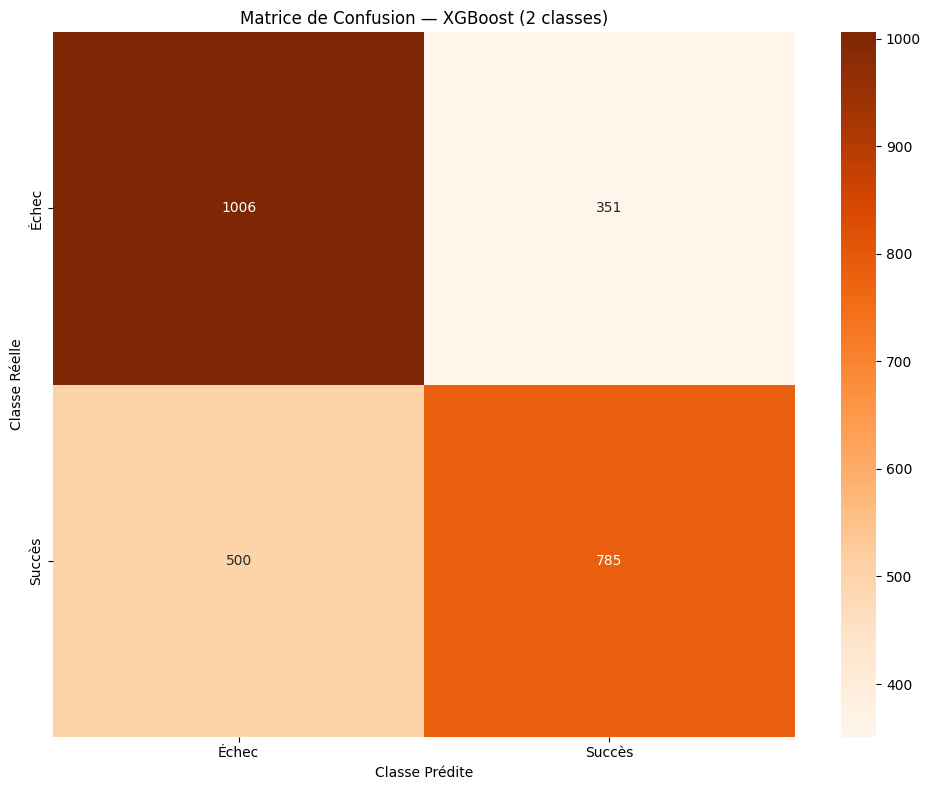

In [175]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_bin, y_pred_bin)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Échec', 'Succès'],
    yticklabels=['Échec', 'Succès']
)
plt.title('Matrice de Confusion — XGBoost (2 classes)')
plt.xlabel('Classe Prédite')
plt.ylabel('Classe Réelle')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_xgb_2classes.png', dpi=300, bbox_inches='tight')
plt.show()

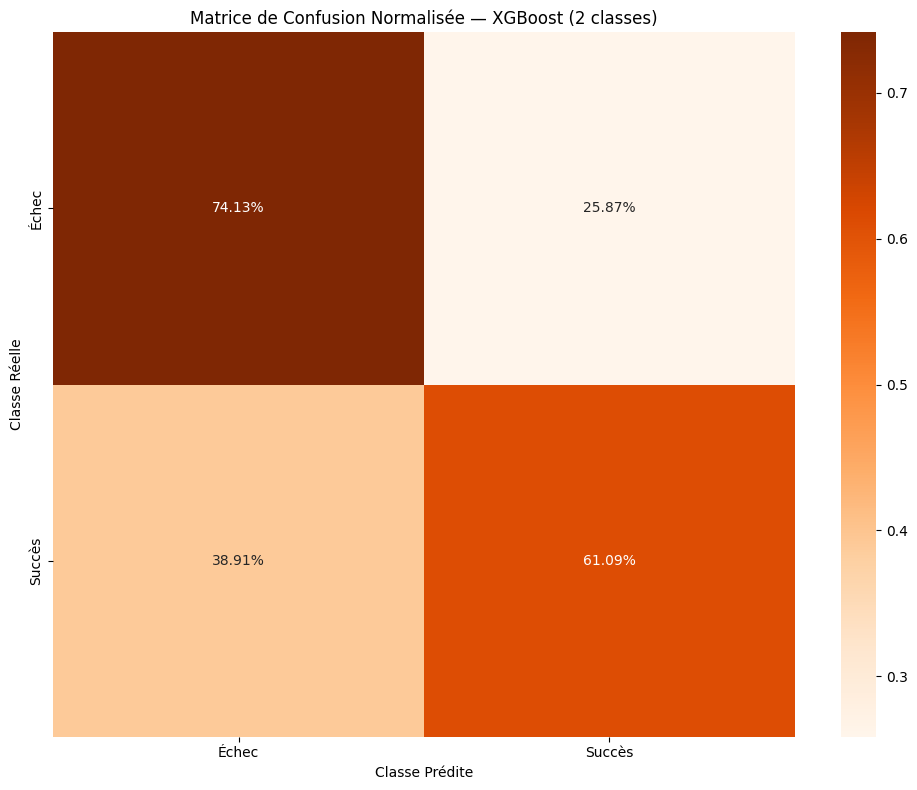

In [176]:
labels_classes = ['Échec', 'Succès']

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized, annot=True, fmt='.2%', cmap='Oranges',
    xticklabels=labels_classes,
    yticklabels=labels_classes
)
plt.title('Matrice de Confusion Normalisée — XGBoost (2 classes)')
plt.xlabel('Classe Prédite')
plt.ylabel('Classe Réelle')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_xgb_normalized_2classes.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Feature Importance

**Avantage sans PCA** : On peut directement voir quelles variables originales sont les plus importantes.

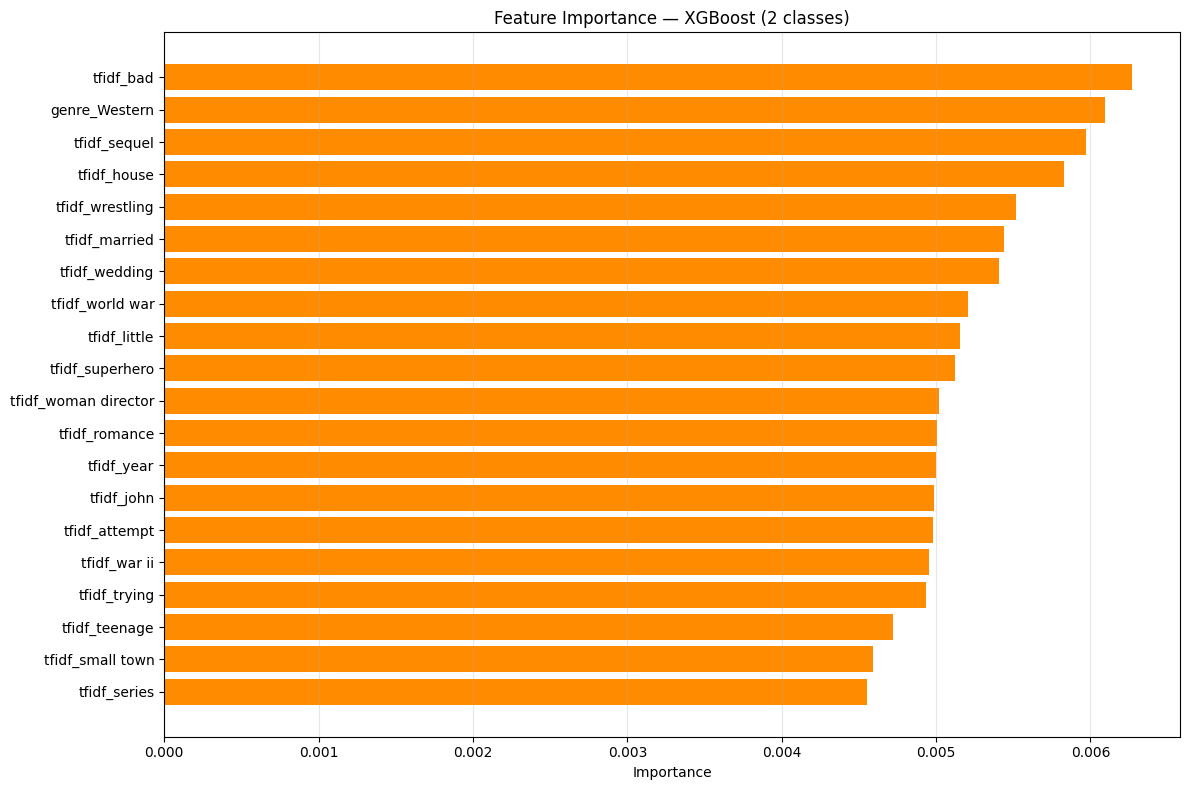


Top 20 variables les plus importantes (2 classes) :
   1. tfidf_bad                      : 0.0063
   2. genre_Western                  : 0.0061
   3. tfidf_sequel                   : 0.0060
   4. tfidf_house                    : 0.0058
   5. tfidf_wrestling                : 0.0055
   6. tfidf_married                  : 0.0054
   7. tfidf_wedding                  : 0.0054
   8. tfidf_world war                : 0.0052
   9. tfidf_little                   : 0.0052
  10. tfidf_superhero                : 0.0051
  11. tfidf_woman director           : 0.0050
  12. tfidf_romance                  : 0.0050
  13. tfidf_year                     : 0.0050
  14. tfidf_john                     : 0.0050
  15. tfidf_attempt                  : 0.0050
  16. tfidf_war ii                   : 0.0050
  17. tfidf_trying                   : 0.0049
  18. tfidf_teenage                  : 0.0047
  19. tfidf_small town               : 0.0046
  20. tfidf_series                   : 0.0046


In [177]:
# ==============================
# FEATURE IMPORTANCE — Modèle final (2 classes)
# ==============================

importances = xgb_bin.feature_importances_
indices = np.argsort(importances)[::-1]

n_top = 20

plt.figure(figsize=(12, 8))
plt.barh(
    range(n_top),
    importances[indices[:n_top]][::-1],
    color='darkorange'
)
plt.yticks(
    range(n_top),
    [feature_names[indices[i]] for i in range(n_top)][::-1]
)
plt.title('Feature Importance — XGBoost (2 classes)')
plt.xlabel('Importance')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_xgb_2classes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTop 20 variables les plus importantes (2 classes) :")
for i in range(n_top):
    print(f"  {i+1:2d}. {feature_names[indices[i]]:<30} : {importances[indices[i]]:.4f}")

=== IMPORTANCE PAR CATÉGORIE ===
  Texte (TF-IDF total)  : 0.9295 (92.9%)
  Genres (total)        : 0.0547 (5.5%)
  budget_scaled          : 0.0032 (0.3%)
  runtime_scaled         : 0.0039 (0.4%)
  adult_encoded          : 0.0035 (0.3%)
  is_english             : 0.0023 (0.2%)
  release_year           : 0.0029 (0.3%)


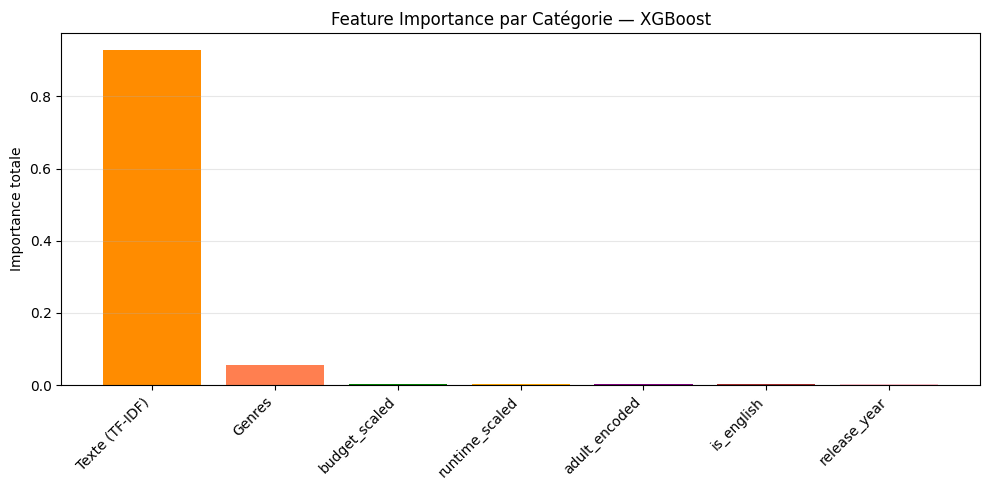

In [178]:
# --- Feature Importance par catégorie ---
# Vérifier que lengths correspondent
if len(feature_names) != len(importances):
    print(f" Attention : feature_names ({len(feature_names)}) != importances ({len(importances)})")
    # On tronque à la plus petite longueur pour éviter l'erreur
    min_len = min(len(feature_names), len(importances))
    feature_names = feature_names[:min_len]
    importances = importances[:min_len]

# TF-IDF total
tfidf_imp = sum(importances[i] for i, f in enumerate(feature_names) if f.startswith('tfidf_'))

# Genres total
genre_imp = sum(importances[i] for i, f in enumerate(feature_names) if f.startswith('genre_'))

# Autres features
other_names = ['budget_scaled', 'runtime_scaled', 'adult_encoded', 'is_english', 'release_year']
other_imp = {name: importances[feature_names.index(name)] 
             for name in other_names if name in feature_names}

# Affichage
print("=== IMPORTANCE PAR CATÉGORIE ===")
print(f"  Texte (TF-IDF total)  : {tfidf_imp:.4f} ({tfidf_imp*100:.1f}%)")
print(f"  Genres (total)        : {genre_imp:.4f} ({genre_imp*100:.1f}%)")
for name, imp in other_imp.items():
    print(f"  {name:<22} : {imp:.4f} ({imp*100:.1f}%)")

# Graphique
categories = ['Texte (TF-IDF)', 'Genres'] + list(other_imp.keys())
values = [tfidf_imp, genre_imp] + list(other_imp.values())

plt.figure(figsize=(10, 5))
plt.bar(categories, values, color=['darkorange', 'coral', 'green', 'orange', 'purple', 'brown', 'pink'][:len(categories)])
plt.title('Feature Importance par Catégorie — XGBoost')
plt.ylabel('Importance totale')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_xgb_categories.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Analyse des erreurs par classe

In [179]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_bin, y_pred_bin)

print("=" * 58)
print("=== ANALYSE DES ERREURS PAR CLASSE (2 classes) ===")
print("=" * 58)
print(f"{'Classe':<10} {'VP':<8} {'FP':<8} {'FN':<8} {'Precision':<12} {'Recall':<12}")
print("-" * 58)

for c in range(2):
    vp = ((y_pred_bin == c) & (y_test_bin == c)).sum()
    fp = ((y_pred_bin != c) & (y_test_bin == c)).sum()  # FN = y_test=c mais prédit != c
    fn = ((y_pred_bin == c) & (y_test_bin != c)).sum()  # FP = prédit=c mais y_test != c
    prec = vp / (vp + fn) if (vp + fn) > 0 else 0
    rec = vp / (vp + fp) if (vp + fp) > 0 else 0
    classe_nom = 'Échec' if c == 0 else 'Succès'
    print(f"{classe_nom:<10} {vp:<8} {fn:<8} {fp:<8} {prec:<12.4f} {rec:<12.4f}")

print("-" * 58)
print(f"{'ACCURACY':<10} {accuracy:<34.4f} ({accuracy*100:.2f}%)")
print("=" * 58)

=== ANALYSE DES ERREURS PAR CLASSE (2 classes) ===
Classe     VP       FP       FN       Precision    Recall      
----------------------------------------------------------
Échec      1006     500      351      0.6680       0.7413      
Succès     785      351      500      0.6910       0.6109      
----------------------------------------------------------
ACCURACY   0.6779                             (67.79%)


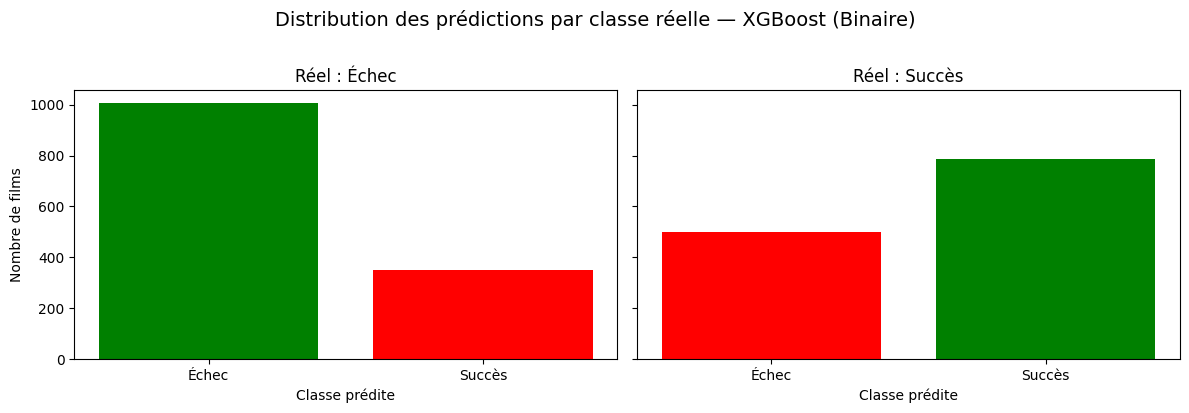

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for c in range(2):
    mask = y_test_bin == c 
    preds_for_class = y_pred_bin[mask]
    unique, counts = np.unique(preds_for_class, return_counts=True)
    
    colors = ['green' if u == c else 'red' for u in unique]
    axes[c].bar(unique, counts, color=colors)
    axes[c].set_title(f'Réel : {"Échec" if c == 0 else "Succès"}')
    axes[c].set_xlabel('Classe prédite')
    axes[c].set_xticks([0, 1])
    axes[c].set_xticklabels(['Échec', 'Succès'])

axes[0].set_ylabel('Nombre de films')
plt.suptitle('Distribution des prédictions par classe réelle — XGBoost (Binaire)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/analyse_erreurs_xgb_binaire.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Sauvegarde du modèle et des résultats

In [181]:
# ==============================
# Sauvegarde des résultats au format CSV
# ==============================

import pandas as pd
import joblib
from datetime import datetime

# Récupération des métriques déjà calculées
# (ces variables doivent exister - elles viennent des cellules précédentes)
try:
    # Métriques TEST
    accuracy_test = accuracy_score(y_test_bin, y_pred_bin)
    precision_test = precision_score(y_test_bin, y_pred_bin, average='binary')
    recall_test = recall_score(y_test_bin, y_pred_bin, average='binary')
    f1_test = f1_score(y_test_bin, y_pred_bin, average='binary')
    
    # Métriques TRAIN (calculées à l'étape 1)
    y_pred_train_bin = xgb_bin.predict(X_train_bin)
    accuracy_train = accuracy_score(y_train_bin, y_pred_train_bin)
    precision_train = precision_score(y_train_bin, y_pred_train_bin, average='binary')
    recall_train = recall_score(y_train_bin, y_pred_train_bin, average='binary')
    f1_train = f1_score(y_train_bin, y_pred_train_bin, average='binary')
    
except NameError as e:
    print(f"Erreur: {e}")
    print("   Certaines métriques ne sont pas définies.")
    print("   Vérifiez que l'étape 1 (analyse train/test) a été exécutée.")
    # On continue quand même avec les métriques disponibles

# Création du dictionnaire de résultats
resultats_xgb = {
    # Métadonnées
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'modele': 'XGBoost (2 classes)',
    'probleme': 'Classification binaire (Echec vs Succes)',
    
    # Hyperparamètres
    'n_estimators': xgb_bin.n_estimators,
    'learning_rate': xgb_bin.learning_rate,
    'max_depth': xgb_bin.max_depth,
    'min_child_weight': xgb_bin.min_child_weight,
    'subsample': xgb_bin.subsample,
    'colsample_bytree': xgb_bin.colsample_bytree,
    'gamma': xgb_bin.gamma,
    'reg_alpha': xgb_bin.reg_alpha,
    'reg_lambda': xgb_bin.reg_lambda,
    'best_iteration': xgb_bin.best_iteration if hasattr(xgb_bin, 'best_iteration') else None,
    
    # Métriques TRAIN
    'accuracy_train': accuracy_train,
    'precision_train': precision_train,
    'recall_train': recall_train,
    'f1_train': f1_train,
    
    # Métriques TEST
    'accuracy_test': accuracy_test,
    'precision_test': precision_test,
    'recall_test': recall_test,
    'f1_test': f1_test,
    
    # Informations sur les données
    'n_features': X_train_bin.shape[1],
    'n_train_samples': len(y_train_bin),
    'n_test_samples': len(y_test_bin),
    'classes': '0=Echec, 1=Succes',
    'pca': 'Non',
    
    # Performance
    'early_stopping_rounds': 50
}

# Sauvegarde en CSV
df_resultats = pd.DataFrame([resultats_xgb])
csv_path = '../data/processed/resultats_xgb_2classes.csv'
df_resultats.to_csv(csv_path, index=False)
# Sauvegarde des prédictions XGBoost
np.save('../data/processed/y_pred_xgb_2classes.npy', y_pred_bin)
# Sauvegarde du modèle
model_path = '../data/processed/model_xgb_2classes.joblib'
joblib.dump(xgb_bin, model_path)

print("\n" + "=" * 60)
print("RESULTATS SAUVEGARDES AVEC SUCCES")
print("=" * 60)
print(f"Fichier CSV : {csv_path}")
print(f"Modele      : {model_path}")
print("-" * 60)
print("Recapitulatif des metriques sauvegardees :")
print(f"   Accuracy TEST  : {accuracy_test:.2%}")
print(f"   F1-score TEST  : {f1_test:.4f}")
print(f"   Accuracy TRAIN : {accuracy_train:.2%}")
print(f"   F1-score TRAIN : {f1_train:.4f}")
print("=" * 60)

import os
print(f"\nChemin absolu : {os.path.abspath(csv_path)}")


RESULTATS SAUVEGARDES AVEC SUCCES
Fichier CSV : ../data/processed/resultats_xgb_2classes.csv
Modele      : ../data/processed/model_xgb_2classes.joblib
------------------------------------------------------------
Recapitulatif des metriques sauvegardees :
   Accuracy TEST  : 67.79%
   F1-score TEST  : 0.6485
   Accuracy TRAIN : 81.70%
   F1-score TRAIN : 0.7949

Chemin absolu : C:\Users\omaha\PSID_Data_IA\movie-profitability-predictor\data\processed\resultats_xgb_2classes.csv
